# HR Employee Performance Analysis
**Name:** Divya  
**Course:** Data Preprocessing and EDA Lab (DPEL) — SIT Pune  
**Dataset:** HR Analytics — Employee Performance Dataset  
**Goal:** Analyse employee data to understand key factors affecting performance ratings and build a prediction model using Random Forest.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error



#Data Loading:

In [12]:
from google.colab import files
uploaded = files.upload()  # run this → click "Choose File" → select your CSV

data = pd.read_csv('Uncleaned_employees_final.csv')
print("Shape:", data.shape)


Saving Uncleaned_employees_final.csv to Uncleaned_employees_final (4).csv
Shape: (17417, 13)


##A) DATA UNDERSTANDING

In [13]:
data.head()


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [14]:
print("the number of rows and coloumns is: ",data.shape) #checking the numbetr of rows and columns
data.dtypes



the number of rows and coloumns is:  (17417, 13)


,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,float64
length_of_service,int64


In [15]:

# ---- Dataset Description ----
print("\n\n--- Dataset Shape ---")
print("Rows:", data.shape[0], "| Columns:", data.shape[1])





--- Dataset Shape ---
Rows: 17417 | Columns: 13


In [16]:

print("\n\n--- Column Names & Data Types ---")
print(data.dtypes)




--- Column Names & Data Types ---
employee_id                int64
department                object
region                    object
education                 object
gender                    object
recruitment_channel       object
no_of_trainings            int64
age                        int64
previous_year_rating     float64
length_of_service          int64
KPIs_met_more_than_80      int64
awards_won                 int64
avg_training_score         int64
dtype: object


In [17]:

print("\n\n--- First 5 Rows ---")
data.head()




--- First 5 Rows ---


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [18]:
data.isna().sum() #finding the total number of na in each columns

,0
employee_id,0
department,0
region,0
education,771
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1363
length_of_service,0


In [19]:
print("\nMissing % per column:")
print(round(data.isnull().sum() / len(data) * 100, 2))




Missing % per column:
employee_id              0.00
department               0.00
region                   0.00
education                4.43
gender                   0.00
recruitment_channel      0.00
no_of_trainings          0.00
age                      0.00
previous_year_rating     7.83
length_of_service        0.00
KPIs_met_more_than_80    0.00
awards_won               0.00
avg_training_score       0.00
dtype: float64


In [20]:
data.duplicated().sum() ## ounting the total duplicate rows

np.int64(2)

In [21]:
print("\n--- Duplicate Rows ---")
print("Total duplicates:", data.duplicated().sum())




--- Duplicate Rows ---
Total duplicates: 2


In [22]:
data = data.drop_duplicates()   # Removes duplicate rows
data.head(10)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
5,46232,Procurement,region_7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68
6,54542,Finance,region_2,Bachelors,m,other,1,33,5.0,3,1,0,57
7,67269,Analytics,region_22,Bachelors,m,sourcing,2,36,3.0,3,0,0,85
8,66174,Technology,region_7,Masters & above,m,other,1,51,4.0,11,0,0,75
9,76303,Technology,region_22,Bachelors,m,sourcing,1,29,5.0,2,1,0,76


In [23]:
print("\n--- Basic Statistics ---")
data.describe()



--- Basic Statistics ---


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17415.000000,17415.000000,17415.000000,16052.000000,17415.000000,17415.000000,17415.000000,17415.000000
mean,39082.285214,1.250761,34.807982,3.345751,5.801493,0.358886,0.023371,63.177720
std,22708.049139,0.595720,7.694464,1.265194,4.175632,0.479687,0.151082,13.418314
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19280.500000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39115.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


## B) DATA PREPROCESSING


In [24]:
# filling na
data["previous_year_rating"] = data["previous_year_rating"].fillna(data["previous_year_rating"].median())

data["education"] = data["education"].fillna(data["education"].mode()[0])
data.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,3.0,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [25]:
data['gender'] = data['gender'].astype(str).str.lower().replace({'m': 'Male', 'f': 'Female'})

# Rename columns for clarity
data = data.rename(columns={
    'KPIs_met_more_than_80': 'KPIs_above_80',
    'no_of_trainings': 'training_taken',
    'previous_year_rating': 'prior_rating'
})

# Fix data types
data['prior_rating'] = data['prior_rating'].astype(float)
data['KPIs_above_80'] = data['KPIs_above_80'].astype(int)
data['awards_won'] = data['awards_won'].astype(int)



In [26]:
cols_cat= ['department', 'region', 'education', 'gender', 'recruitment_channel']
for col in cols_cat:
    data[col] = data[col].astype('category')
print("\nData types after cleaning:")

print(data.dtypes)



Data types after cleaning:
employee_id               int64
department             category
region                 category
education              category
gender                 category
recruitment_channel    category
training_taken            int64
age                       int64
prior_rating            float64
length_of_service         int64
KPIs_above_80             int64
awards_won                int64
avg_training_score        int64
dtype: object


In [27]:
print("\nCleaned dataset shape:", data.shape)
data.head()




Cleaned dataset shape: (17415, 13)


,employee_id,department,region,education,gender,recruitment_channel,training_taken,age,prior_rating,length_of_service,KPIs_above_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,Male,sourcing,1,24,3.0,1,1,0,77
1,74430,HR,region_4,Bachelors,Female,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,Male,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,Female,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,Male,sourcing,1,30,4.0,7,0,0,61


##C) FEATURE TRANSFORMATION


In [28]:
# ---- Step 4: Label Encoding ----
# Applied to: gender, recruitment_channel (binary/low-cardinality)
# NOT applied to employee_id or age (not categorical)


In [29]:
le = LabelEncoder()
data["gender_encoded"] = le.fit_transform(data["gender"])
data["recruitment_channel_encoded"] = le.fit_transform(data["recruitment_channel"])

print("\nLabel Encoding done for: gender, recruitment_channel")
print(data[["gender", "gender_encoded", "recruitment_channel", "recruitment_channel_encoded"]].head(10))



Label Encoding done for: gender, recruitment_channel
   gender  gender_encoded recruitment_channel  recruitment_channel_encoded
0    Male               1            sourcing                            2
1  Female               0               other                            0
2    Male               1               other                            0
3  Female               0               other                            0
4    Male               1            sourcing                            2
5    Male               1            sourcing                            2
6    Male               1               other                            0
7    Male               1            sourcing                            2
8    Male               1               other                            0
9    Male               1            sourcing                            2


###Step 5: One-Hot Encoding

In [30]:
# Applied to: department, education (multi-class nominal, no ordinal relationship)
# NOT including employee_id, age, or avg_training_score (numerical columns)


In [31]:
data_ohe = data.copy()
data_ohe = pd.get_dummies(data_ohe, columns=['department', 'education'], drop_first=True)

print("\nOne-Hot Encoding done for: department, education")
print("Shape after OHE:", data_ohe.shape)
ohe_cols = [c for c in data_ohe.columns if 'department_' in c or 'education_' in c]
print("New OHE columns:", ohe_cols)



One-Hot Encoding done for: department, education
Shape after OHE: (17415, 23)
New OHE columns: ['department_Finance', 'department_HR', 'department_Legal', 'department_Operations', 'department_Procurement', 'department_R&D', 'department_Sales & Marketing', 'department_Technology', 'education_Below Secondary', 'education_Masters & above']


### Step 6: Standardization (Z-score Scaling)


In [32]:
# Justification: features have different ranges (age: 20-60, score: 40-100)
# Standardization is preferred over min-max as it handles outliers better


In [33]:
scaler = StandardScaler()
cols_to_scale = ['age', 'avg_training_score', 'length_of_service', 'training_taken', 'prior_rating']

data_scaled = data.copy()
data_scaled[cols_to_scale] = scaler.fit_transform(data_scaled[cols_to_scale])

print("\nStandardization applied to:", cols_to_scale)
print("\nMean after scaling (should be ~0):")
print(data_scaled[cols_to_scale].mean().round(3))
print("\nStd after scaling (should be ~1):")
print(data_scaled[cols_to_scale].std().round(3))




Standardization applied to: ['age', 'avg_training_score', 'length_of_service', 'training_taken', 'prior_rating']

Mean after scaling (should be ~0):
age                   0.0
avg_training_score   -0.0
length_of_service    -0.0
training_taken        0.0
prior_rating         -0.0
dtype: float64

Std after scaling (should be ~1):
age                   1.0
avg_training_score    1.0
length_of_service     1.0
training_taken        1.0
prior_rating          1.0
dtype: float64


##D) EDA AND VISUALIZATION


In [34]:
plot_data = data.copy()

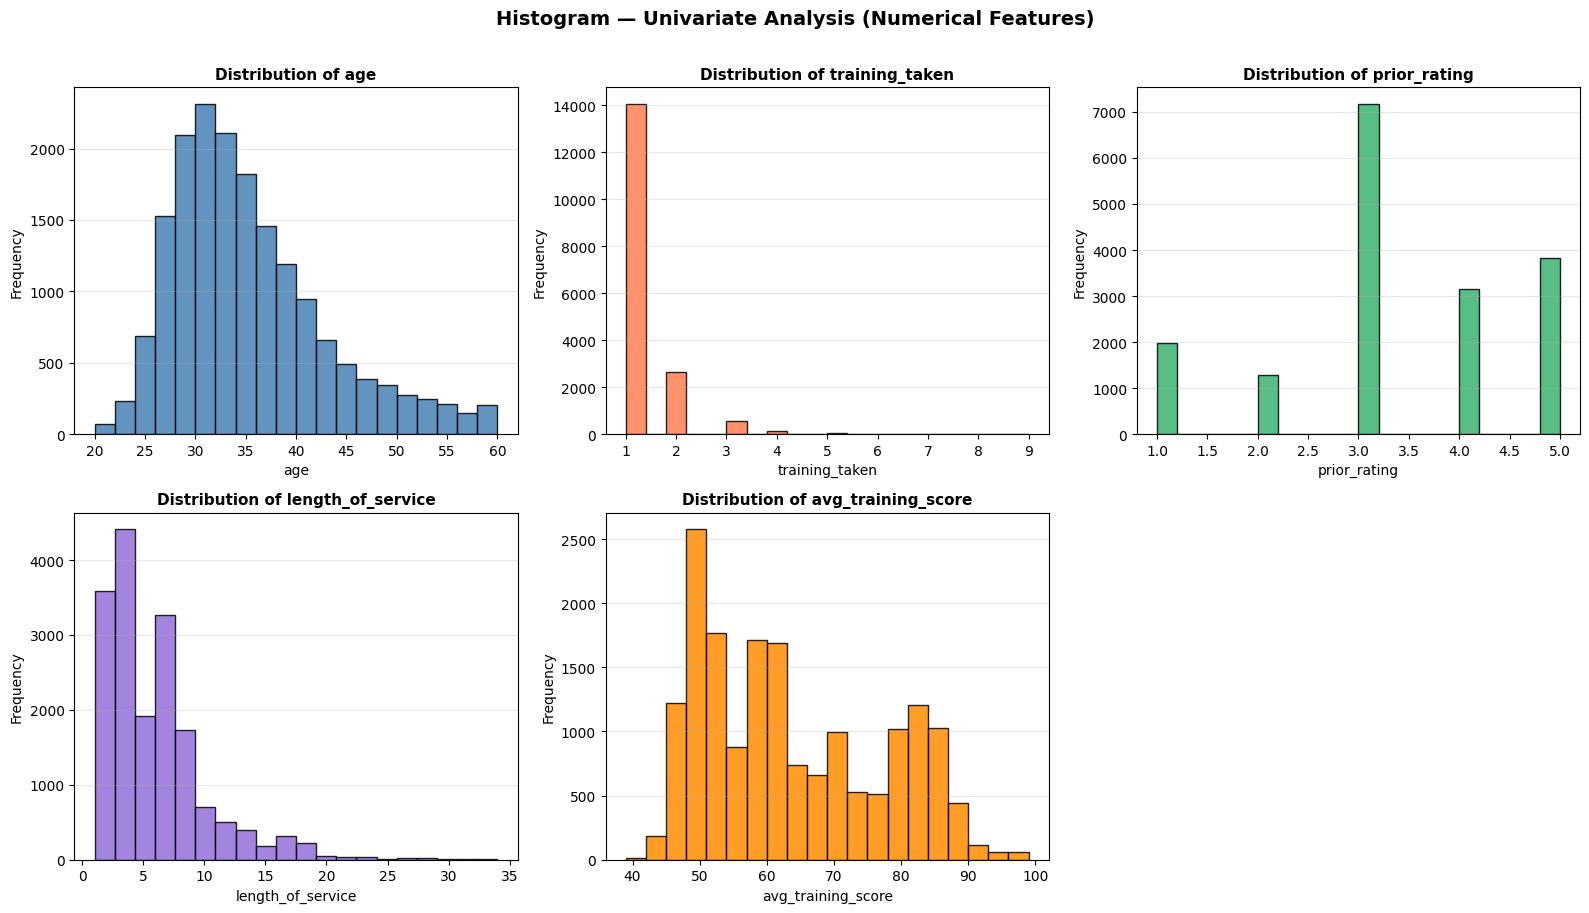

Insight: Most employees are aged 25–40. avg_training_score is roughly normally distributed around 60–70.


In [35]:
# ---- 10. UNIVARIATE ANALYSIS - Histograms ----
num_features = ['age', 'training_taken', 'prior_rating', 'length_of_service', 'avg_training_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'darkorange']

for i, col in enumerate(num_features):
    axes[i].hist(plot_data[col].dropna(), bins=20, color=colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Histogram — Univariate Analysis (Numerical Features)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogram_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Most employees are aged 25–40. avg_training_score is roughly normally distributed around 60–70.")



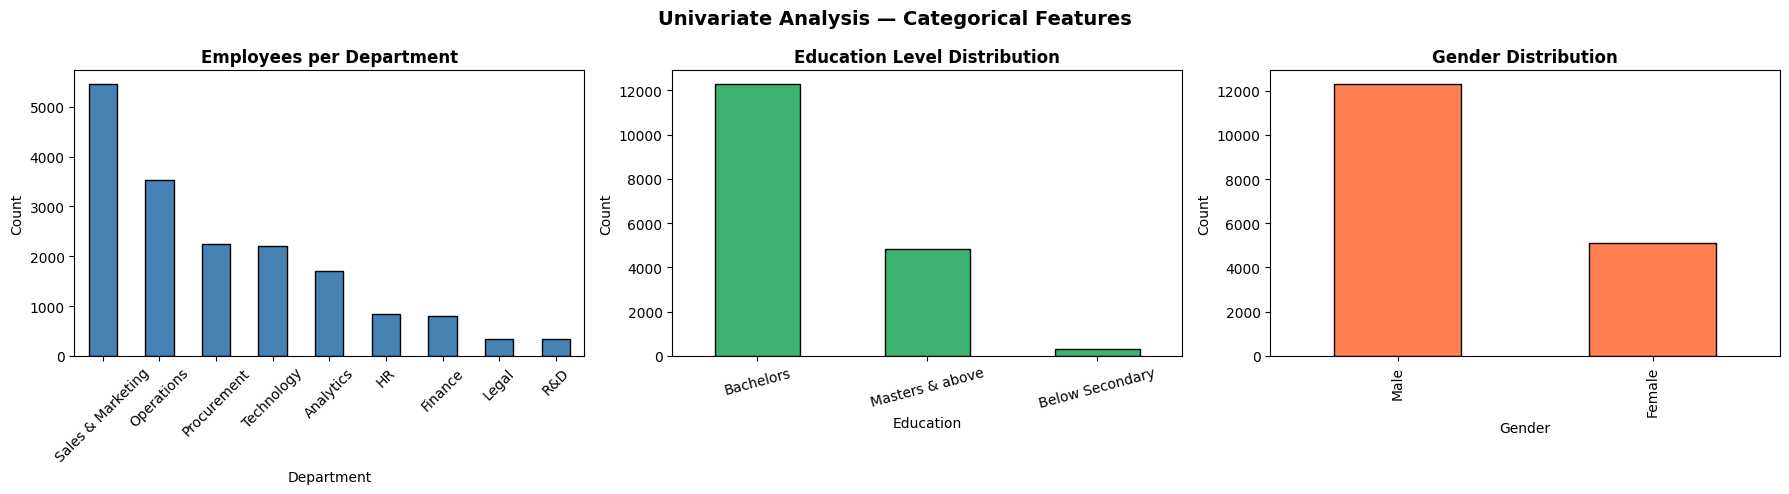

Insight: Sales & Marketing has the most employees. Bachelors is the most common education level.


In [36]:
# ---- Univariate - Categorical Bar Charts ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data['department'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Employees per Department', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Department', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

plot_data['education'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Education Level Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Education', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

plot_data['gender'].value_counts().plot(kind='bar', ax=axes[2], color='coral', edgecolor='black')
axes[2].set_title('Gender Distribution', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Gender', fontsize=10)
axes[2].set_ylabel('Count', fontsize=10)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Sales & Marketing has the most employees. Bachelors is the most common education level.")



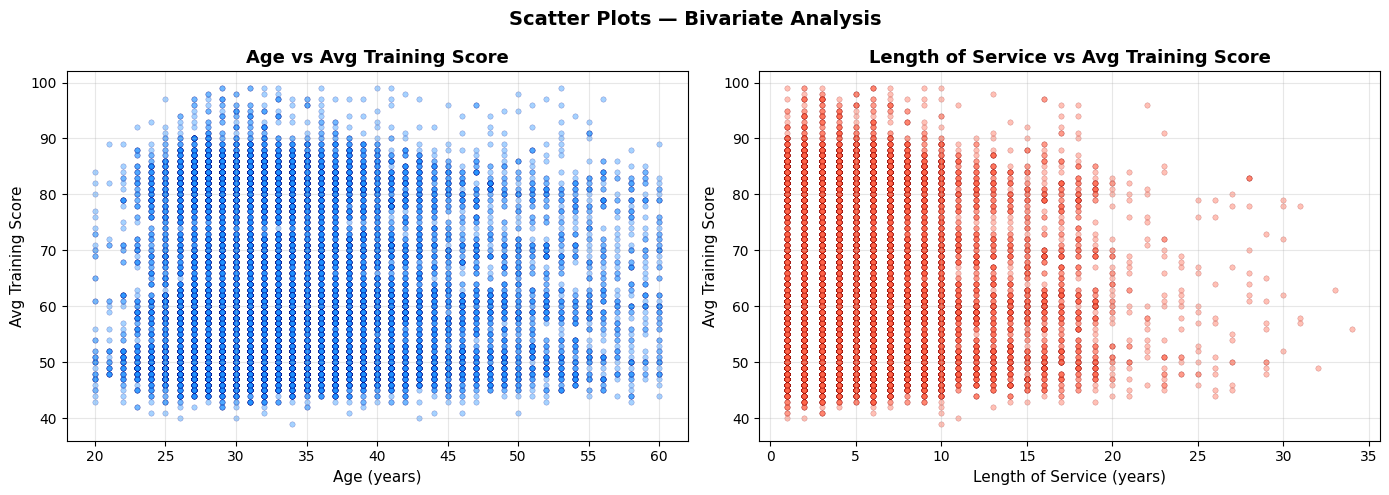

Insight: No strong linear trend. Training score is fairly consistent across all age and service groups.


In [37]:
# ---- 11. BIVARIATE ANALYSIS - Scatter Plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(plot_data['age'], plot_data['avg_training_score'],
                alpha=0.4, color='dodgerblue', edgecolors='navy', linewidths=0.3, s=15)
axes[0].set_title('Age vs Avg Training Score', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Age (years)', fontsize=11)
axes[0].set_ylabel('Avg Training Score', fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].scatter(plot_data['length_of_service'], plot_data['avg_training_score'],
                alpha=0.4, color='tomato', edgecolors='darkred', linewidths=0.3, s=15)
axes[1].set_title('Length of Service vs Avg Training Score', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Length of Service (years)', fontsize=11)
axes[1].set_ylabel('Avg Training Score', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Scatter Plots — Bivariate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: No strong linear trend. Training score is fairly consistent across all age and service groups.")



/tmp/ipykernel_982/551192216.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_order = plot_data.groupby('department')['avg_training_score'].median().sort_values(ascending=False).index
/tmp/ipykernel_982/551192216.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='department', y='avg_training_score',


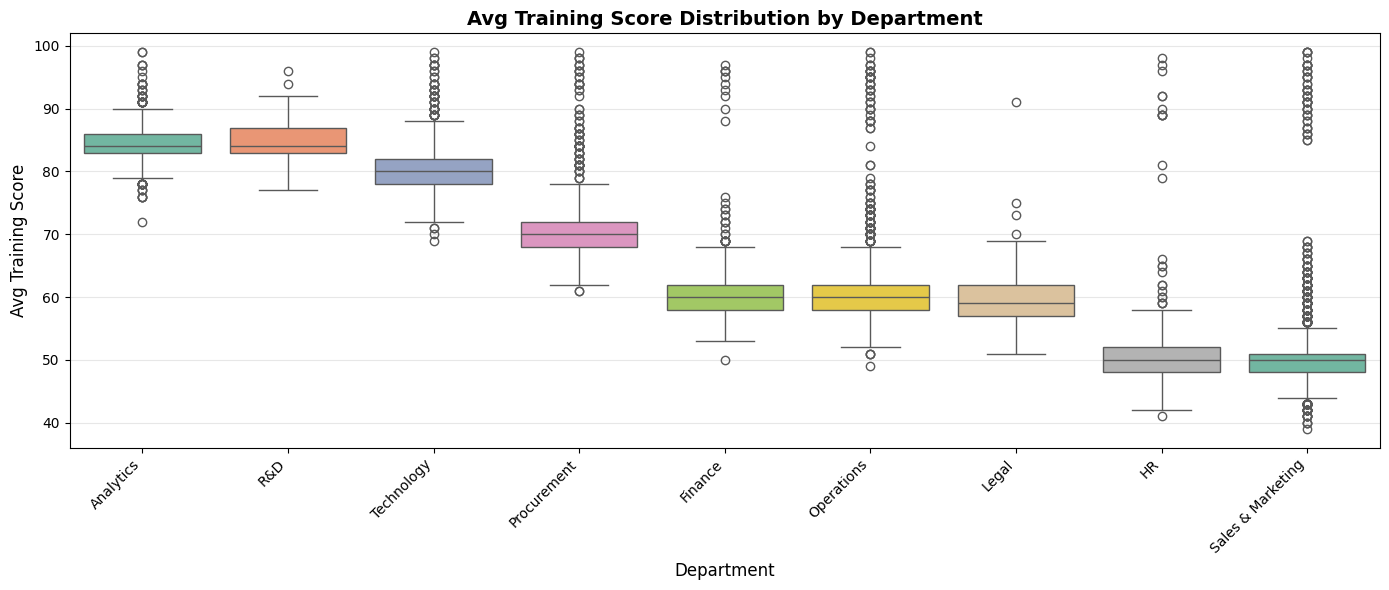

Insight: Technology and Analytics departments show higher median training scores.


In [38]:
# ---- Boxplot: Avg Training Score by Department ----
plt.figure(figsize=(14, 6))
dept_order = plot_data.groupby('department')['avg_training_score'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_data, x='department', y='avg_training_score',
            order=dept_order, palette='Set2')
plt.title('Avg Training Score Distribution by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Avg Training Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_department.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Technology and Analytics departments show higher median training scores.")



/tmp/ipykernel_982/1131864858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='KPIs_above_80', y='avg_training_score',


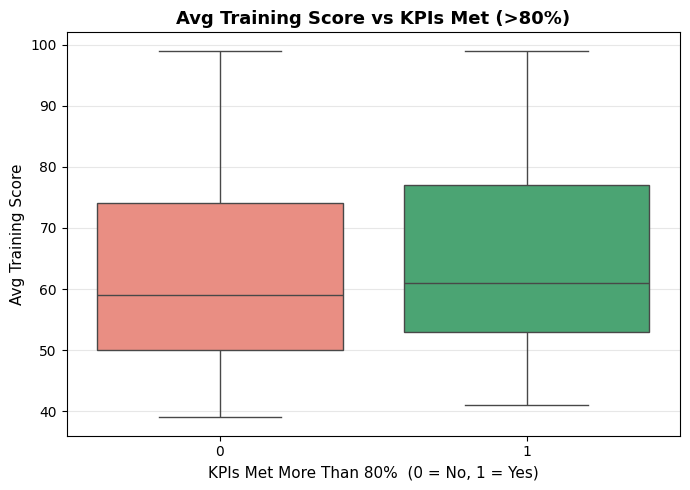

Insight: Employees who met KPIs tend to have higher avg training scores.


In [39]:
# ---- Boxplot: KPIs vs Avg Training Score ----
plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_data, x='KPIs_above_80', y='avg_training_score',
            palette=['salmon', 'mediumseagreen'])
plt.title('Avg Training Score vs KPIs Met (>80%)', fontsize=13, fontweight='bold')
plt.xlabel('KPIs Met More Than 80%  (0 = No, 1 = Yes)', fontsize=11)
plt.ylabel('Avg Training Score', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_kpi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Employees who met KPIs tend to have higher avg training scores.")


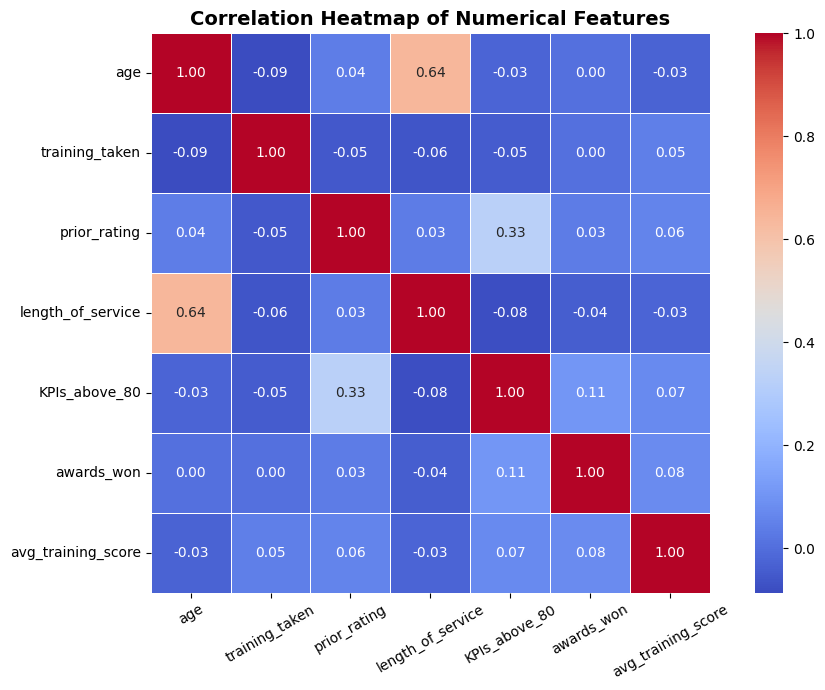

Insight: KPIs_above_80 and prior_rating show moderate correlation. avg_training_score has low correlation with age.


In [40]:
# ---- 12. HEATMAP — Correlation Matrix ----
plt.figure(figsize=(10, 7))
corr_cols = ['age', 'training_taken', 'prior_rating',
             'length_of_service', 'KPIs_above_80', 'awards_won', 'avg_training_score']
corr_matrix = plot_data[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 10}, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10, rotation=30)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: KPIs_above_80 and prior_rating show moderate correlation. avg_training_score has low correlation with age.")



In [ ]:
# ---- Z-Score Outlier Scatter Plots (Correct axes + labels) ----
z_threshold = 3
plot_features = ['age', 'avg_training_score', 'length_of_service', 'training_taken', 'prior_rating']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    mean = plot_data[feature].mean()
    std = plot_data[feature].std()

    if std == 0:
        continue

    z = (plot_data[feature] - mean) / std
    normal_mask = z.abs() <= z_threshold
    outlier_mask = z.abs() > z_threshold

    axes[i].scatter(plot_data.index[normal_mask], plot_data[feature][normal_mask],
                    s=5, color='steelblue', alpha=0.5, label='Normal')
    axes[i].scatter(plot_data.index[outlier_mask], plot_data[feature][outlier_mask],
                    s=30, color='red', alpha=0.8, label='Outlier')
    axes[i].set_title(f'Outliers: {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Employee Index', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Z-Score Outlier Detection per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('zscore_outliers.png', dpi=150, bbox_inches='tight')
plt.show()



## E) MULTIVARIATE ANALYSIS


In [ ]:
# Use relevant numeric columns — exclude employee_id
df_multi = plot_data[["training_taken", "prior_rating", "length_of_service",
                       "avg_training_score", "awards_won", "KPIs_above_80"]]

print("\n--- Multivariate DataFrame Info ---")
df_multi.info()

# Histograms for each column
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(df_multi.columns):
    axes[i].hist(df_multi[col].dropna(), bins=10, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Histogram of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Distribution — Multivariate Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ---- KDE Density Plots (Univariate) ----
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.kdeplot(plot_data[col].dropna(), ax=axes[i], fill=True, color=colors[i], alpha=0.6)
    axes[i].set_title(f'Density: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'{col} Values', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle('KDE Density Plots — Univariate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kde_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
#Spearman Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df_multi.corr("spearman"), annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5)
plt.title("Spearman Correlation Heatmap", fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:

# Pairplot
sns.pairplot(df_multi, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle("Pairplot — Multivariate Analysis", y=1.02, fontsize=13, fontweight='bold')
plt.show()


In [ ]:

# Variance
print("\n--- Variance ---")
print(df_multi.var().round(4))


In [ ]:

# Covariance
print("\n--- Covariance ---")
print(df_multi.cov().round(4))

plt.figure(figsize=(9, 6))
sns.heatmap(df_multi.cov(), annot=True, fmt=".2f", cmap='PuOr', linewidths=0.5)
plt.title("Covariance Heatmap", fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# PREDICTION — Random Forest Regressor


In [ ]:
X = df_multi.drop("prior_rating", axis=1)
y = df_multi["prior_rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("\nTrain/Test Split:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

